In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2025-04-13 14:02:31.761714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-13 14:02:31.851902: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-13 14:02:31.875220: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-13 14:02:32.075447: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
shape = (1,128,128)
pixel_size = 9e-4  # [m]
wavelength = 300e-6  # [m]
distance = 0.8 # [m]



Rectangular U

In [3]:
#set random seed
# np.random.seed(42)
# U = tf.random.uniform( #Measured amplitude
#     shape = shape,
#     minval=1e-3,
#     maxval=1,
#     dtype=tf.float32,
# )

# U = tf.zeros(shape, dtype=tf.float32)

# # Define the 20x20 region
# center_x, center_y = 128 // 2, 128 // 2  # Center of the 128x128 grid
# half_size = 20 // 2

# # Set the 20x20 region to 1
# U = tf.tensor_scatter_nd_update(
#     U,
#     indices=tf.constant([[0, x, y] for x in range(center_x - half_size, center_x + half_size)
#                          for y in range(center_y - half_size, center_y + half_size)]),
#     updates=tf.ones((20 * 20,), dtype=tf.float32)
# )
# U.numpy()

# U

U = 0

In [4]:
# U= tf.zeros(shape, dtype=tf.float32)

Cross shape

In [5]:
# # Create a tensor filled with zeros
# U = tf.zeros(shape, dtype=tf.float32)

# # Define the center of the grid
# center_x, center_y = 128 // 2, 128 // 2

# # Define the size of the lines
# line_length = 20  # Length of each line

# # Create indices for the vertical line
# vertical_indices = [[0, x, center_y] for x in range(center_x - line_length // 2, center_x + line_length // 2)]

# # Create indices for the horizontal line
# horizontal_indices = [[0, center_x, y] for y in range(center_y - line_length // 2, center_y + line_length // 2)]

# # Combine the indices
# indices = tf.constant(vertical_indices + horizontal_indices)

# # Set the values at the indices to 1
# U = tf.tensor_scatter_nd_update(
#     U,
#     indices=indices,
#     updates=tf.ones(len(indices), dtype=tf.float32)
# )

# U

Circle shape

In [6]:
# Create a tensor filled with zeros
U = tf.zeros(shape, dtype=tf.float32)

# Define the center of the grid
center_x, center_y = 128 // 2, 128 // 2

# Define the radius of the circle
radius = 20

# Create a grid of coordinates
x = tf.range(128, dtype=tf.float32)  # Ensure the range is float
y = tf.range(128, dtype=tf.float32)
X, Y = tf.meshgrid(x, y)

# Calculate the distance from the center
distance_circle = tf.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)

# Create a mask for the circle
circle_mask = tf.cast(distance_circle <= radius, tf.float32)

# Add the circle to the tensor
U = U + tf.expand_dims(circle_mask, axis=0)

U

I0000 00:00:1744552956.911652  147381 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744552957.290207  147381 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744552957.290277  147381 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744552957.310940  147381 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744552957.311038  147381 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2b:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

<tf.Tensor: shape=(1, 128, 128), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>

In [7]:
#set random seed
np.random.seed(42)
# phase = tf.random.uniform(shape, minval=0.0, maxval=2 * np.pi, dtype=tf.float32)
""""""
# phase = tf.zeros(shape, dtype=tf.float32)

# # Define the 20x20 region
# center_x, center_y = 128 // 2, 128 // 2  # Center of the 128x128 grid
# half_size = 20 // 2

# # Set the 20x20 region to 1
# phase = tf.tensor_scatter_nd_update(
#     phase,
#     indices=tf.constant([[0, x, y] for x in range(center_x - half_size, center_x + half_size)
#                          for y in range(center_y - half_size, center_y + half_size)]),
#     updates=tf.ones((20 * 20,), dtype=tf.float32)
# )

""""""
# Create a tensor filled with zeros
phase = tf.zeros(shape, dtype=tf.float32)


""""""
# # Define the 20x20 region
# center_x, center_y = 128 // 2, 128 // 2  # Center of the 128x128 grid
# half_size = 20 // 2

# # Set the 20x20 region to 1
# phase = tf.tensor_scatter_nd_update(
#     phase,
#     indices=tf.constant([[0, x, y] for x in range(center_x - half_size, center_x + half_size)
#                          for y in range(center_y - half_size, center_y + half_size)]),
#     updates=tf.ones((20 * 20,), dtype=tf.float32)
# )
phase.shape

TensorShape([1, 128, 128])

In [8]:
phase.numpy()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)

In [9]:
# U2 = tf.cast(U, dtype=tf.complex64)
# U == tf.math.real(U2)

In [10]:
print("U min:", tf.reduce_min(U).numpy(), "U max:", tf.reduce_max(U).numpy())

U min: 0.0 U max: 1.0


In [11]:
phase

<tf.Tensor: shape=(1, 128, 128), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>

In [12]:
# Properly calculate the measured complex field
U = tf.cast(U, dtype=tf.complex64) # Converts the amplitude U to a complex tensor
output = U * tf.exp(tf.complex(0.0, phase))
output

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


<tf.Tensor: shape=(1, 128, 128), dtype=complex64, numpy=
array([[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        ...,
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]],
      dtype=complex64)>

In [13]:
phase

<tf.Tensor: shape=(1, 128, 128), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>

In [14]:
# Separate the real and imaginary parts of U
U_real = tf.math.real(output)
U_imag = tf.math.imag(output)
U_separated = tf.stack([U_real, U_imag], axis=0)  # Shape: (2, 128, 128)
# U_separated[0,:,:]
U_imag

<tf.Tensor: shape=(1, 128, 128), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>

In [15]:
H, W = (128,128)
dx = pixel_size
x = np.arange(-W//2, W//2) * dx
y = np.arange(-H//2, H//2) * dx
X, Y = np.meshgrid(x, y)

r2 = X**2 + Y**2
k = 2 * np.pi / wavelength

arg = k * distance + (np.pi * r2) / (wavelength * distance)
h_complex = tf.constant(1 / (1j * wavelength * distance) * tf.exp(tf.complex(tf.cast(0.0, tf.float64), tf.cast(arg, tf.float64))), dtype=tf.complex128)
h_real = tf.math.real(h_complex)
h_imag = tf.math.imag(h_complex)
h_real = tf.cast(h_real, dtype=tf.float32)
h_imag = tf.cast(h_imag, dtype=tf.float32)
h_separated = tf.stack([h_real, h_imag], axis=0)  # Shape: (2, 128, 128)
h_real.shape

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


TensorShape([128, 128])

In [16]:
print("h_real min:", tf.reduce_min(h_real).numpy(), "h_real max:", tf.reduce_max(h_real).numpy())
print("h_imag min:", tf.reduce_min(h_imag).numpy(), "h_imag max:", tf.reduce_max(h_imag).numpy())

h_real min: -4166.6523 h_real max: 4166.6426
h_imag min: -4166.6426 h_imag max: 4166.6562


In [17]:
h_imag.dtype,h_real.dtype,h_separated.dtype

(tf.float32, tf.float32, tf.float32)

### Controlling the Number of Axes Added
The following cell ensures that `h_real` and `h_imag` have exactly the shape `(128, 128, 1, 1)` by checking their current shape before adding axes.

In [18]:
# Ensure h_real has shape (128, 128, 1, 1)
while len(h_real.shape) < 4:
    h_real = tf.expand_dims(h_real, axis=-1)

# Ensure h_imag has shape (128, 128, 1, 1)
while len(h_imag.shape) < 4:
    h_imag = tf.expand_dims(h_imag, axis=-1)

print(h_real.shape, h_imag.shape)  # Should print (128, 128, 1, 1)

(128, 128, 1, 1) (128, 128, 1, 1)


In [19]:
re_re = tf.nn.conv2d(
    input=tf.expand_dims(U_real,0),
    filters=h_real,
    data_format='NCHW', #channel first NHWC - channel last
    strides=[1, 1, 1, 1], # [batch, in_height, in_width, out_channels] po kazdym elemencie
    padding='SAME',
)

2025-04-13 14:02:40.122185: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1744552960.221872  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.253671  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.279974  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.281953  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.288232  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.308751  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


In [20]:
im_im = tf.nn.conv2d(
    input=tf.expand_dims(U_imag,0),
    filters=h_imag,
    data_format='NCHW', #channel first NHWC - channel last
    strides=[1, 1, 1, 1], # [batch, in_height, in_width, out_channels] po kazdym elemencie
    padding='SAME',
)

re_im = tf.nn.conv2d(
    input=tf.expand_dims(U_real,0),
    filters=h_imag,
    data_format='NCHW', #channel first NHWC - channel last
    strides=[1, 1, 1, 1], # [batch, in_height, in_width, out_channels] po kazdym elemencie
    padding='SAME',
)

im_re = tf.nn.conv2d(
    input=tf.expand_dims(U_imag,0),
    filters=h_real,
    data_format='NCHW', #channel first NHWC - channel last
    strides=[1, 1, 1, 1], # [batch, in_height, in_width, out_channels] po kazdym elemencie
    padding='SAME',
)

W0000 00:00:1744552960.399551  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.400757  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.402398  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.404091  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.410174  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.415082  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.416810  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.417823  147381 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744552960.419400  147381 gp

In [21]:
print("re_re min:", tf.reduce_min(re_re).numpy(), "re_re max:", tf.reduce_max(re_re).numpy())
print("im_im min:", tf.reduce_min(im_im).numpy(), "im_im max:", tf.reduce_max(im_im).numpy())

re_re min: -1195685.9 re_re max: 249550.4
im_im min: 0.0 im_im max: 0.0


In [22]:
out_real = tf.squeeze(re_re - im_im, axis=0)
out_imag = tf.squeeze(re_im + im_re, axis=0)
out_real.shape, out_imag.shape

(TensorShape([1, 128, 128]), TensorShape([1, 128, 128]))

In [23]:
out=tf.stack([out_real, out_imag], axis=-1)
out.shape

TensorShape([1, 128, 128, 2])

In [24]:
out[0, :, :, 0]


<tf.Tensor: shape=(128, 128), dtype=float32, numpy=
array([[ -2403.2925 ,  -6761.5645 , -12544.152  , ...,  -3779.2493 ,
           579.0327 ,    572.864  ],
       [ -6761.5684 , -12215.443  , -10350.303  , ..., -13186.482  ,
         -7732.618  ,   -839.07324],
       [-12544.148  , -10350.293  ,   1647.8351 , ..., -12743.002  ,
        -14936.861  ,  -7744.1016 ],
       ...,
       [ -3779.2468 , -13186.4795 , -12742.996  , ..., -13913.313  ,
         -4506.079  ,   5823.774  ],
       [   579.0342 ,  -7732.61   , -14936.859  , ...,  -4506.0776 ,
          3805.556  ,   7235.7256 ],
       [   572.86597,   -839.07776,  -7744.096  , ...,   5823.7783 ,
          7235.7266 ,   5096.3687 ]], dtype=float32)>

Converting to intensity

In [25]:
# Calculate intensity
out_real = out[..., 0]  # Real part
out_imag = out[..., 1]  # Imaginary part
intensity = tf.square(out_real) + tf.square(out_imag)
tf.reduce_mean(intensity), tf.reduce_max(intensity), tf.reduce_min(intensity)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


(<tf.Tensor: shape=(), dtype=float32, numpy=114646970000.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4422755000000.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4968862.0>)

### Comparing Intensity with Original U
The following cell compares the intensity heatmap with the original `U` amplitude.

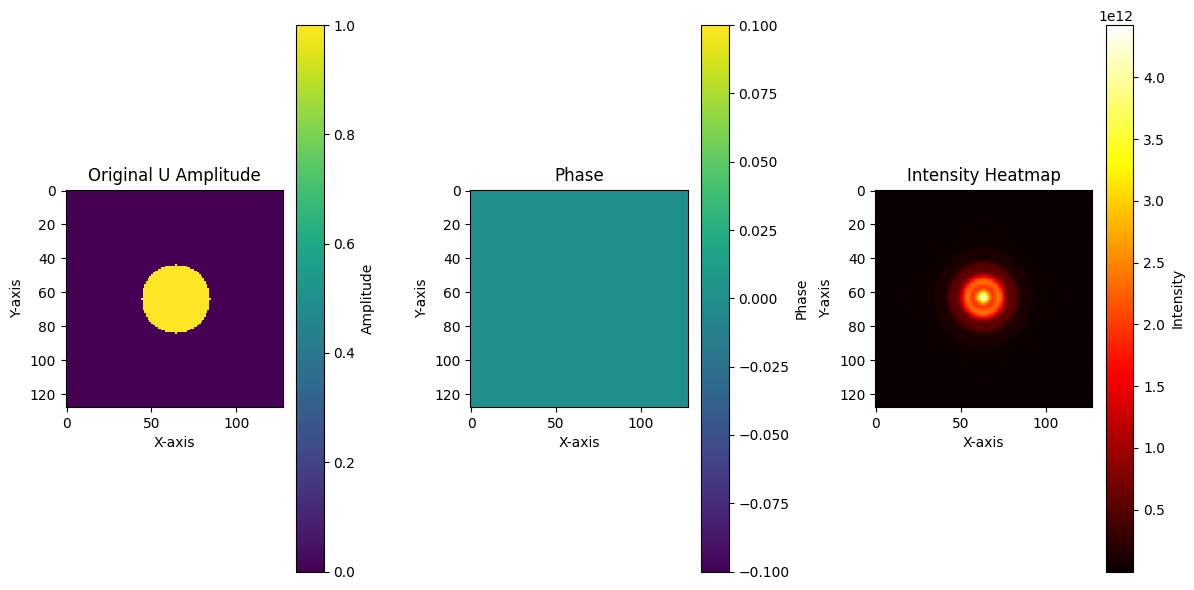

In [26]:
plt.figure(figsize=(12, 6))
# intensity_scaled = intensity / tf.reduce_max(intensity)
intensity_scaled = intensity

# Plot original U amplitude
plt.subplot(1, 3, 1)  # Adjusted to 1, 3, 1 for three subplots
plt.imshow(tf.math.abs(U[0]), cmap='viridis', interpolation='nearest')
plt.colorbar(label='Amplitude')
plt.title('Original U Amplitude')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

# # Plot phase heatmap
plt.subplot(1, 3, 2)  # Adjusted to 1, 3, 2 for the second subplot
plt.imshow(phase[0], cmap='viridis', interpolation='nearest')  # Use phase[0] to match shape
plt.colorbar(label='Phase')
plt.title('Phase')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

# Plot intensity heatmap
plt.subplot(1, 3, 3)  # Adjusted to 1, 3, 3 for the third subplot
plt.imshow(intensity_scaled[0], cmap='hot', interpolation='nearest')
plt.colorbar(label='Intensity')
plt.title('Intensity Heatmap')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.tight_layout()
plt.show()